# Multiple-Testing — which 'winning' p-value can you trust? 🎯
### Test 100 calendar effects and a few will look real by luck — so how do you tell?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Trust_a_naive_t%3F: Busted](https://img.shields.io/badge/Trust_a_naive_t%3F-Busted-8b949e?style=flat-square)

Run *one* test at the usual bar (a *t*-stat above 2) and a false alarm happens about 1 time in 20. Run **38 tests at once** and the chance that *at least one* fires by pure luck is about **83%** — nearly certain. This notebook screens a battery of calendar 'effects' (Mondays, turn-of-month, the Santa rally…) and shows the three standard fixes — **Bonferroni**, **Holm**, and the **false-discovery-rate** method — sorting the real from the lucky.

> 📓 **This is the plain-language layer.** Want the FWER-vs-FDR maths, the power curves and the Monte-Carlo calibration? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from multiple_testing import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE, "SPY"))

HAVE_REAL = _have_cache()

def real_battery():
    return data.load_real(ticker="SPY", fetch=False)

print("real battery cache present:", HAVE_REAL)


real battery cache present: True


## The answer first

| Question | Answer |
|---|---|
| If I test 100 effects that are all fake, how many 'win'? | **About 4 or 5.** At a *t* > 2 bar, ~4.5% of pure-noise tests pass by luck — so a 100-effect search hands you a fistful of false discoveries every time. |
| Which fix should I use? | **Bonferroni / Holm** if you can't tolerate *any* false alarm (strict); **Benjamini-Hochberg** if you'll accept a few false leads to find more real effects (powerful). Holm beats Bonferroni for free. |
| What happened on the real SPY calendar battery? | **The count collapsed.** 13 effects passed the naive bar; only **10** survive the false-discovery method and **7** survive the strictest one. |
| So can I trust a backtest *t*-stat? | **Not on its own.** A *t* means nothing until you say how many tests it was the best of — and which correction you applied. |

> The headline isn't an effect — it's a *method*. The naive count of 'significant' results is the most over-sold number in finance; correcting for the search is what separates a discovery from a coincidence.

## 1 · The claim

Open any finance blog and you'll find it: *"The turn-of-month effect is statistically significant — t-stat over 2!"* The implicit promise is that a *t* above 2 means a 1-in-20 fluke at worst, so the effect is almost surely real.

That promise holds for **one** pre-registered test. But nobody tests one calendar effect. They quietly try Mondays, Fridays, the first five days, the last five days, each month, quarter-ends, the Santa rally, sell-in-May… and report the ones that 'worked.' The strong version of the claim: *the surviving t-stats are real signal.* We'll show that with a battery of tests, several 'significant' results are guaranteed by luck alone.

## 2 · So what?

This is the single most expensive mistake in quantitative finance. Every 'factor zoo' paper, every viral backtest, every '90% win-rate' thread is one search away from being a false discovery dressed as a *t*-stat. If you can't tell the lucky winners from the real ones, you'll fund the lucky ones — and watch them die out of sample. The fix isn't exotic: it's three lines of arithmetic that have been standard in medicine and genetics for decades. Finance just keeps forgetting to use them.

## 3 · How would we even know?

We run a controlled experiment, then a real one:

1. **A fake market where nothing is real.** 100 calendar 'effects', all pure noise. Count how many pass the naive *t* > 2 bar — those are *all* false alarms, by construction.
2. **A fake market with a known answer.** Plant a real edge in 10 of 100 effects. A good method finds the 10 (**power**) without waving through the 90 fakes (**false discoveries**).
3. **The real tape.** 38 named calendar effects on SPY since 1995. Watch the 'discovery' count shrink as we go from naive → false-discovery-rate → strictest.

If the corrections are doing their job, the fake-market null returns **zero** discoveries, the planted edges are **recovered**, and the real count **collapses** toward what survives an honest bar.

## 4 · The teardown — let's actually look

**First: a market where there is provably nothing to find.** 100 effects, all noise. How many 'significant winners' does each method report?

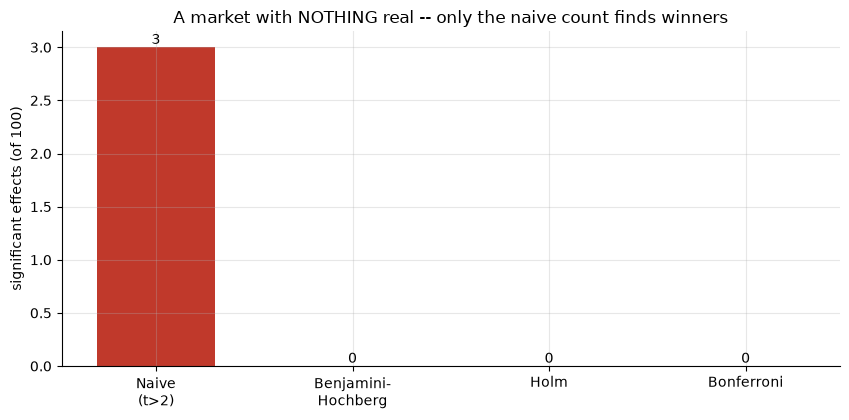

null discoveries — naive: 3 | BH: 0 | Holm: 0 | Bonferroni: 0


In [2]:
r0, t0, _ = data.synthetic_battery(n_days=2520, m_effects=100, n_true=0, seed=346)
res0 = st.run_experiment(r0, t0, alpha=0.05, t_thresh=2.0)
c0 = res0['counts']
labels = ['Naive\n(t>2)', 'Benjamini-\nHochberg', 'Holm', 'Bonferroni']
vals = [c0['naive'], c0['bh'], c0['holm'], c0['bonferroni']]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(labels, vals, color=[RED, AMBER, GREEN, GREEN], width=.6)
ax.set_ylabel('significant effects (of 100)')
ax.set_title('A market with NOTHING real -- only the naive count finds winners')
for i, v in enumerate(vals):
    ax.annotate(str(v), (i, v), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print('null discoveries — naive:', c0['naive'], '| BH:', c0['bh'],
      '| Holm:', c0['holm'], '| Bonferroni:', c0['bonferroni'])

On a tape with **zero** real effects, the naive bar still hands you ~3 'discoveries' — every one a false alarm. The three corrections all report **0**, which is the truth. That gap is the whole problem in one chart.

**Now plant a real edge in 10 of 100 effects.** A good method must *find* the 10 without drowning in the 90 fakes. Here's power (real effects found) and false positives, by method:

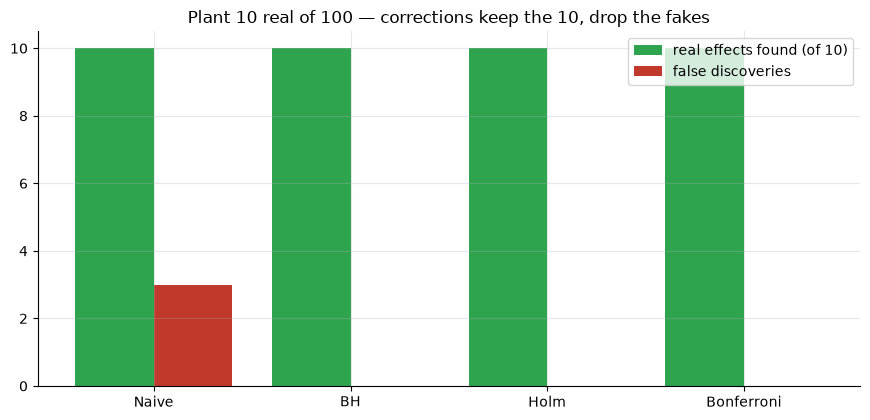

found real / false: {'Naive': (10, 3), 'BH': (10, 0), 'Holm': (10, 0), 'Bonferroni': (10, 0)}


In [3]:
r1, t1, _ = data.synthetic_battery(n_days=2520, m_effects=100, n_true=10, seed=346)
res1 = st.run_experiment(r1, t1, alpha=0.05, t_thresh=2.0)
sc = res1['score']
procs = ['naive', 'bh', 'holm', 'bonferroni']; names = ['Naive', 'BH', 'Holm', 'Bonferroni']
tp = [sc[p]['true_pos'] for p in procs]; fp = [sc[p]['false_pos'] for p in procs]
x = np.arange(len(procs))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(x-0.2, tp, width=.4, color=GREEN, label='real effects found (of 10)')
ax.bar(x+0.2, fp, width=.4, color=RED, label='false discoveries')
ax.set_xticks(x); ax.set_xticklabels(names); ax.legend()
ax.set_title('Plant 10 real of 100 — corrections keep the 10, drop the fakes')
plt.tight_layout(); plt.show()
print('found real / false:', {n: (sc[p]['true_pos'], sc[p]['false_pos']) for p, n in zip(procs, names)})

All four find the 10 real effects here — but the naive bar also drags in 3 fakes (a 23% false-discovery rate), while the corrections add **none**. You get the same real discoveries *and* a clean report.

**Finally, the real tape: 38 calendar effects on SPY since 1995.** Watch the 'discovery' count collapse as the bar gets honest.

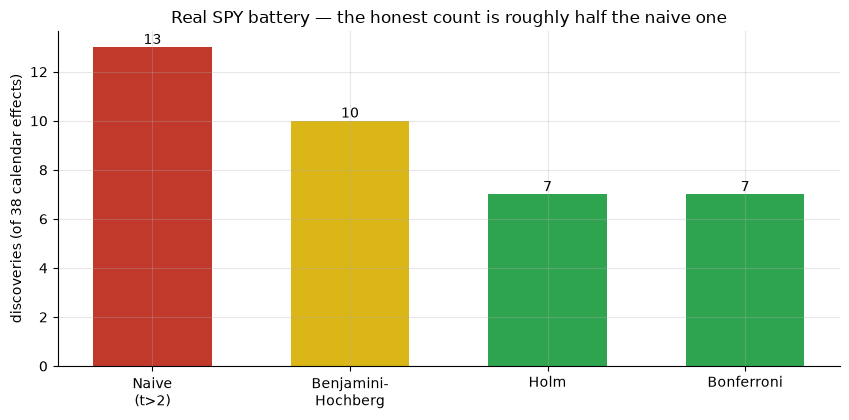

of 38 effects — naive 13, BH 10, Holm 7, Bonferroni 7


In [4]:
if HAVE_REAL:
    rets, _ = real_battery()
    res = st.run_experiment(rets, alpha=0.05, t_thresh=2.0)
    c = res['counts']
    m = c['m_effects']
    naive, bh, holm, bonf = c['naive'], c['bh'], c['holm'], c['bonferroni']
else:
    m, naive, bh, holm, bonf = 38, 13, 10, 7, 7
    print('OFFLINE — frozen real numbers from docs/results.md')
labels = ['Naive\n(t>2)', 'Benjamini-\nHochberg', 'Holm', 'Bonferroni']
vals = [naive, bh, holm, bonf]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(labels, vals, color=[RED, AMBER, GREEN, GREEN], width=.6)
ax.set_ylabel(f'discoveries (of {m} calendar effects)')
ax.set_title('Real SPY battery — the honest count is roughly half the naive one')
for i, v in enumerate(vals):
    ax.annotate(str(v), (i, v), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'of {m} effects — naive {naive}, BH {bh}, Holm {holm}, Bonferroni {bonf}')

On the real battery, **13** effects pass the naive bar — but with 38 simultaneous tests, the chance of *at least one* false alarm is ~83%. Only **10** survive the false-discovery method and **7** survive the strictest. The survivors are the turn-of-month family — the one calendar seasonal that is genuinely robust. The rest were the search talking.

## 5 · The verdict

- **Signal — None.** This is a method demo, not an anomaly. On the fake null there is nothing to find; the naive 'winners' are luck. On the real tape the only survivors are a seasonal the desk already documents. No new edge is claimed.
- **Tradability — Mirage.** The naive count invents discoveries that don't exist. A pile of marginal calendar tilts at high turnover is nothing to trade.
- **Can you trust a naive *t*? — Busted.** With 38 tests the family-wise false-positive chance is ~83%, and the naive count overstates the honest one by nearly 2×. A *t*-stat is meaningless without its trial count and a correction.

## 6 · Could you actually trade it?

There's nothing here to trade — that's the point. The 'effects' that fail correction were never real, so trading them is paying turnover to harvest noise. The handful that survive (turn-of-month) are tiny, capacity-limited, and already crowded. The real payoff of this study is *defensive*: before you allocate to anybody's '*t*-stat over 2' backtest, ask how many strategies they tried, and apply the correction yourself. It's three lines of code and it will save you from most of the factor zoo.

## 7 · Going further 🚪

- **The best-of-N angle.** [Study 343 — Data-Mining-Roulette](../../343-data-mining-roulette/) spins random *rules* and runs White's Reality Check on the single luckiest one. This study is the family-wide complement — correcting *across* many named effects at once.
- **The overfitting angle.** [Study 344 — Backtest-Overfitting](../../344-backtest-overfitting/) uses the Deflated Sharpe Ratio and PBO when you tune *one* strategy to death.
- **Swap the battery.** Fork this and feed it a panel of *factor* returns instead of calendar effects, and watch the same collapse from naive to corrected.

*Think your favourite calendar effect is real? Fork this, add it to the battery alongside the 37 others, and see whether it's still standing after Benjamini-Hochberg.*